# LLM Gateways: Routing, Resilience, and Cost Control

## Why a Single API Call Is Never the Whole Story

This notebook builds the **complete mental model for an LLM Gateway** from first principles — starting with the everyday pain of calling multiple LLM providers directly, then assembling the routing, load balancing, rate limiting, fallback, and caching machinery that production systems rely on.

Every concept is demonstrated on the same running example:

> **A small fleet of mock LLM providers** — `gpt-4o`, `gpt-4o-mini`, `claude-3-5-haiku`, `groq-llama-70b`, and a free `local-llama-8b` — each with its own cost, latency, and reliability profile.

We use **simulated providers** instead of real API calls. This keeps the notebook fully self-contained (no API keys, no network calls, deterministic output) while preserving every behavior that matters: variable latency, variable cost, and realistic failure rates. Near the end, we show what the exact same logic looks like with a real gateway library (LiteLLM) so the jump to production is a small one, not a leap.

| Step | Concept                          | Key Idea                                                | Why It Matters                           |
| ---- | -------------------------------- | ------------------------------------------------------- | ---------------------------------------- |
| 1    | The Multi-Provider Problem       | Why calling providers directly doesn't scale            | Sets up the pain the gateway solves      |
| 2    | Unified Provider Abstraction     | One interface hiding many SDKs                          | Load-bearing for all other features      |
| 3    | Round-Robin & Least-Busy Routing | Spreading load evenly vs. adapting to congestion        | Throughput under variable load           |
| 4    | Latency-Aware Routing            | Learning which provider is fastest, in real time        | Minimize user-facing response time       |
| 5    | Cost-Aware & Weighted Routing    | Sending traffic where it's cheapest, proportionally     | Budget control + canary rollouts         |
| 6    | Rate Limiting & Throttling       | Token buckets and sliding windows                       | Protect budget and provider relationship |
| 7    | Fallback Strategies              | Surviving outages without the caller noticing           | Reliability becomes multiplicative       |
| 8    | Cost Optimization via Caching    | Never pay twice for the same question                   | Highest-leverage cost optimization       |
| 9    | Assembling a Production Gateway  | Combining all of the above into one class               | The complete request lifecycle           |
| 10   | Real-World Gateways & Practices  | LiteLLM, Portkey, Helicone — and a production checklist | From simulation to production            |

---


In [1]:
# Install dependencies (run once)
import subprocess, sys

required = [
    ("numpy", "numpy"),
    ("matplotlib", "matplotlib"),
    ("pandas", "pandas"),
    ("seaborn", "seaborn"),
]

for imp, pkg in required:
    try:
        __import__(imp)
        print(f"  [OK]  {pkg}")
    except ImportError:
        print(f"  Installing {pkg}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])
        print(f"  [OK]  {pkg} installed")

print(
    "\nDependencies ready. No API keys required — every provider in this notebook is simulated."
)

  [OK]  numpy
  [OK]  matplotlib
  [OK]  pandas
  [OK]  seaborn

Dependencies ready. No API keys required — every provider in this notebook is simulated.


In [2]:
import time
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 100, "font.size": 10})
sns.set_theme(style="whitegrid", palette="muted")

random.seed(42)
np.random.seed(42)

print("Libraries loaded. Random seed fixed at 42 for reproducible demos.")

Libraries loaded. Random seed fixed at 42 for reproducible demos.


---

## Part 1 — What Is an LLM Gateway, and Why Do We Need One?

Imagine your application talks to one LLM provider — say OpenAI. Life is simple. Then:

- Product wants a cheaper model for simple tasks
- OpenAI has an outage and every request starts failing
- Finance wants to know exactly how much each team is spending
- A new, faster provider (Groq) shows up and you want to try it without a rewrite

Suddenly you're maintaining direct integrations with three or four different SDKs, each with its own request format, error types, and pricing model. This is the problem an **LLM Gateway** solves.

Think of a gateway as a **smart middleware layer** that sits between your application and every LLM provider it might call:

```
                ┌───────────────────────────┐
                │      Your Application     │
                │ (Chatbot, RAG, Agent, ...) │
                └─────────────┬─────────────┘
                              │
                              ▼
                ┌───────────────────────────┐
                │        LLM GATEWAY        │
                │  - Routing                │
                │  - Fallbacks              │
                │  - Rate limiting          │
                │  - Caching                │
                │  - Cost tracking          │
                └───┬─────┬─────┬─────┬─────┘
                    │     │     │     │
                    ▼     ▼     ▼     ▼
                 GPT-4o Claude Groq  Local
```

Your application code calls the gateway once, with one interface. The gateway decides _which_ provider actually handles the request — and can change its mind mid-flight if something goes wrong.

### The Pain Without a Gateway, and the Relief With One

| Without a Gateway                                        | With a Gateway                                           |
| -------------------------------------------------------- | -------------------------------------------------------- |
| A different SDK/API shape per provider                   | One unified interface for every provider                 |
| No fallback — one outage takes down your app             | Automatic fallback to a healthy provider                 |
| Costs scattered across dashboards, hard to total         | Centralized cost tracking, per user/team                 |
| Switching models means rewriting call sites              | Switching models is a one-line config change             |
| Repeated identical queries cost money every time         | Caching removes the cost of duplicate questions          |
| No shared throttling — one bad actor can burn the budget | Rate limiting protects both your budget and the provider |

Let's make the first row concrete before we fix it.


In [3]:
# The pain of calling providers directly: three different shapes for "ask a question"


def call_openai_directly(prompt):
    """Pretend OpenAI SDK: nested response object, tokens under .usage"""
    return {
        "choices": [{"message": {"content": f"[openai] {prompt[:20]}..."}}],
        "usage": {"total_tokens": 42},
    }


def call_anthropic_directly(prompt):
    """Pretend Anthropic SDK: content is a list of blocks, not a string"""
    return {
        "content": [{"text": f"[anthropic] {prompt[:20]}..."}],
        "usage": {"input_tokens": 12, "output_tokens": 30},
    }


def call_local_model_directly(prompt):
    """Pretend local model server: plain dict, different key names entirely"""
    return {"generated_text": f"[local] {prompt[:20]}...", "token_count": 38}


# Application code has to know about every single shape
prompt = "What is an LLM Gateway?"

r1 = call_openai_directly(prompt)
r2 = call_anthropic_directly(prompt)
r3 = call_local_model_directly(prompt)

print("OpenAI text:   ", r1["choices"][0]["message"]["content"])
print("Anthropic text:", r2["content"][0]["text"])
print("Local text:    ", r3["generated_text"])
print()
print("Notice: three different response shapes, three different token-count fields.")
print("Every call site in your app needs to know all three. Swap providers, and every")
print("call site breaks. This is the brittleness a gateway is designed to remove.")

OpenAI text:    [openai] What is an LLM Gatew...
Anthropic text: [anthropic] What is an LLM Gatew...
Local text:     [local] What is an LLM Gatew...

Notice: three different response shapes, three different token-count fields.
Every call site in your app needs to know all three. Swap providers, and every
call site breaks. This is the brittleness a gateway is designed to remove.


---

## Part 2 — A Unified Provider Abstraction

### Why Do This First?

Every gateway feature we build next — routing, fallback, rate limiting, caching — needs to treat all providers **identically**. If routing logic has to special-case Anthropic's response shape, it stops being reusable. So the very first thing a gateway does is wrap every provider behind one interface: same method name, same input shape, same output shape.

We'll simulate providers instead of calling real APIs. Each `MockLLMProvider` has three properties that matter for every decision a gateway makes:

| Property             | What It Represents                                             |
| -------------------- | -------------------------------------------------------------- |
| `cost_per_1k_tokens` | Dollars per 1,000 tokens (input + output combined, simplified) |
| `base_latency_ms`    | Typical response time, with jitter to mimic real variance      |
| `failure_rate`       | Probability a call raises an error (outage, rate limit, etc.)  |

This is enough to demonstrate every gateway behavior in this notebook — routing, load balancing, rate limiting, fallback, and cost tracking — without needing a single API key.


In [4]:
class ProviderError(Exception):
    """Raised when a simulated provider call fails (outage, rate limit, etc.)."""

    pass


class MockLLMProvider:
    """
    One unified interface for any LLM provider.

    Real gateways (LiteLLM, Portkey, ...) do exactly this under the hood: a thin
    adapter per provider that normalizes the request and response shape, so every
    downstream feature (routing, caching, fallback) can treat all providers the same.
    """

    def __init__(
        self,
        name,
        cost_per_1k_tokens,
        base_latency_ms,
        latency_jitter_ms,
        failure_rate=0.0,
    ):
        self.name = name
        self.cost_per_1k_tokens = cost_per_1k_tokens
        self.base_latency_ms = base_latency_ms
        self.latency_jitter_ms = latency_jitter_ms
        self.failure_rate = failure_rate
        self.in_flight = 0  # concurrent requests currently being served — used by "least-busy" routing

    def complete(self, prompt: str, response_tokens: int = 40):
        """Simulate a single completion call. Raises ProviderError on simulated failure."""
        self.in_flight += 1
        try:
            if random.random() < self.failure_rate:
                raise ProviderError(
                    f"{self.name} failed (simulated outage or rate limit)"
                )

            latency_ms = max(
                5.0, np.random.normal(self.base_latency_ms, self.latency_jitter_ms)
            )
            time.sleep(
                latency_ms / 20000
            )  # scaled down ~20x so the notebook stays fast

            prompt_tokens = len(prompt.split())
            total_tokens = prompt_tokens + response_tokens
            cost_usd = (total_tokens / 1000) * self.cost_per_1k_tokens

            return {
                "provider": self.name,
                "text": f"[{self.name}] response to: {prompt[:30]}...",
                "latency_ms": latency_ms,
                "tokens": total_tokens,
                "cost_usd": cost_usd,
            }
        finally:
            self.in_flight -= 1


def make_providers():
    """Factory so different sections can get fresh, independent provider instances."""
    return {
        "gpt-4o": MockLLMProvider(
            "gpt-4o",
            cost_per_1k_tokens=0.00250,
            base_latency_ms=900,
            latency_jitter_ms=150,
            failure_rate=0.03,
        ),
        "gpt-4o-mini": MockLLMProvider(
            "gpt-4o-mini",
            cost_per_1k_tokens=0.00015,
            base_latency_ms=450,
            latency_jitter_ms=80,
            failure_rate=0.02,
        ),
        "claude-3-5-haiku": MockLLMProvider(
            "claude-3-5-haiku",
            cost_per_1k_tokens=0.00080,
            base_latency_ms=600,
            latency_jitter_ms=100,
            failure_rate=0.02,
        ),
        "groq-llama-70b": MockLLMProvider(
            "groq-llama-70b",
            cost_per_1k_tokens=0.00005,
            base_latency_ms=180,
            latency_jitter_ms=40,
            failure_rate=0.05,
        ),
        "local-llama-8b": MockLLMProvider(
            "local-llama-8b",
            cost_per_1k_tokens=0.0,
            base_latency_ms=1200,
            latency_jitter_ms=300,
            failure_rate=0.01,
        ),
    }


PROVIDERS = make_providers()

summary = pd.DataFrame(
    [
        {
            "provider": p.name,
            "cost_per_1k_tokens": p.cost_per_1k_tokens,
            "base_latency_ms": p.base_latency_ms,
            "failure_rate": p.failure_rate,
        }
        for p in PROVIDERS.values()
    ]
)
print(summary.to_string(index=False))

        provider  cost_per_1k_tokens  base_latency_ms  failure_rate
          gpt-4o             0.00250              900          0.03
     gpt-4o-mini             0.00015              450          0.02
claude-3-5-haiku             0.00080              600          0.02
  groq-llama-70b             0.00005              180          0.05
  local-llama-8b             0.00000             1200          0.01


#### What Just Happened

We built a unified provider abstraction — every LLM, regardless of its native SDK, now speaks the same language: one `.complete()` method, one response shape. This is the foundation that makes every other gateway feature possible: routing, fallback, caching, rate limiting — none of them can work if they have to special-case Anthropic's response shape vs. OpenAI's.

**The gap that motivates Part 3:** Normalization solves the "different SDKs" problem, but it doesn't yet decide _which_ provider should handle each request. If we just pick one at random or always use the same one, we're leaving performance and cost on the table. **Next: routing strategies.**


---

## Part 3 — Request Routing Strategies

### Why Not Just Pick One Provider and Stick With It?

Because "best" depends on what you're optimizing for right now: throughput, latency, cost, or reliability — and those priorities can even change request by request (a coding question wants a strong model; a summary wants a cheap one). A gateway's **router** decides, for each request, which provider should handle it.

| Strategy      | Idea                                                         | Optimizes For                         |
| ------------- | ------------------------------------------------------------ | ------------------------------------- |
| Round-robin   | Cycle through providers in a fixed order                     | Simplicity, fairness                  |
| Least-busy    | Send to whichever provider has the fewest in-flight requests | Throughput under load                 |
| Latency-aware | Send to whichever provider has been fastest recently         | Response time                         |
| Cost-aware    | Send to the cheapest provider that can do the job            | Budget                                |
| Weighted      | Split traffic proportionally (e.g. 70/30) across a pool      | Controlled rollout, capacity matching |

We'll build each of these against the same five mock providers, so you can see directly how the choice of strategy changes where traffic goes.

### Strategy 1 — Round-Robin: "Take Turns"

The simplest possible router: cycle through the provider list in order, one request at a time. No state needed beyond a counter — but it has no idea whether a provider is currently overloaded.


### Predict First

**Before you look at the output below**, make a prediction:

When one provider randomly becomes slow (takes longer to finish requests), which strategy will handle it better?

- **Round-robin** cycles through providers on a fixed schedule, so it keeps sending traffic to the slow provider at the same rate.
- **Least-busy** checks which provider has the fewest in-flight requests right now, so it can steer around congestion.

**Your prediction:** Which strategy will send fewer requests to the slow provider when it hits a rough patch?

In [5]:
def simulate_routing(providers, strategy, n_requests=24, seed=0):
    """
    Simulate dispatching n_requests to a pool of provider names, one at a time.

    Each dispatched request occupies its provider for a random number of "ticks"
    (its service time). Between dispatches, time passes and some in-flight
    requests finish. This lets "least-busy" show its advantage: if one provider
    is slow this round, least-busy notices and routes around it. Round-robin
    has no such awareness and keeps sending traffic on a fixed schedule.
    """
    rng = random.Random(seed)
    queue = {
        p: [] for p in providers
    }  # remaining ticks for each in-flight request, per provider
    assignments = []
    rr_counter = 0

    for _ in range(n_requests):
        # let one tick of time pass: every in-flight request gets one tick closer to done
        for p in providers:
            queue[p] = [t - 1 for t in queue[p] if t - 1 > 0]

        if strategy == "round-robin":
            chosen = providers[rr_counter % len(providers)]
            rr_counter += 1
        elif strategy == "least-busy":
            chosen = min(providers, key=lambda p: len(queue[p]))
        else:
            raise ValueError(strategy)

        service_ticks = rng.randint(1, 5)
        queue[chosen].append(service_ticks)
        assignments.append(chosen)

    return assignments


PROVIDER_POOL = ["gpt-4o-mini", "claude-3-5-haiku", "groq-llama-70b"]

random.seed(7)
rr_assignments = simulate_routing(PROVIDER_POOL, "round-robin", n_requests=24, seed=7)
lb_assignments = simulate_routing(PROVIDER_POOL, "least-busy", n_requests=24, seed=7)

rr_counts = (
    pd.Series(rr_assignments).value_counts().reindex(PROVIDER_POOL, fill_value=0)
)
lb_counts = (
    pd.Series(lb_assignments).value_counts().reindex(PROVIDER_POOL, fill_value=0)
)

print("Round-robin distribution:\n", rr_counts.to_string(), sep="")
print("\nLeast-busy distribution:\n", lb_counts.to_string(), sep="")
print(
    "\n✅ Prediction check: Least-busy sent",
    rr_counts.max() - lb_counts.min(),
    "fewer requests to the most congested provider.",
)
print("Both strategies dispatch the same 24 requests. Round-robin follows a fixed")
print("schedule regardless of load; least-busy adapts to which provider is currently")
print("backed up with slow-to-finish requests.")

Round-robin distribution:
gpt-4o-mini         8
claude-3-5-haiku    8
groq-llama-70b      8

Least-busy distribution:
gpt-4o-mini         10
claude-3-5-haiku     8
groq-llama-70b       6

Both strategies dispatch the same 24 requests. Round-robin follows a fixed
schedule regardless of load; least-busy adapts to which provider is currently
backed up with slow-to-finish requests.


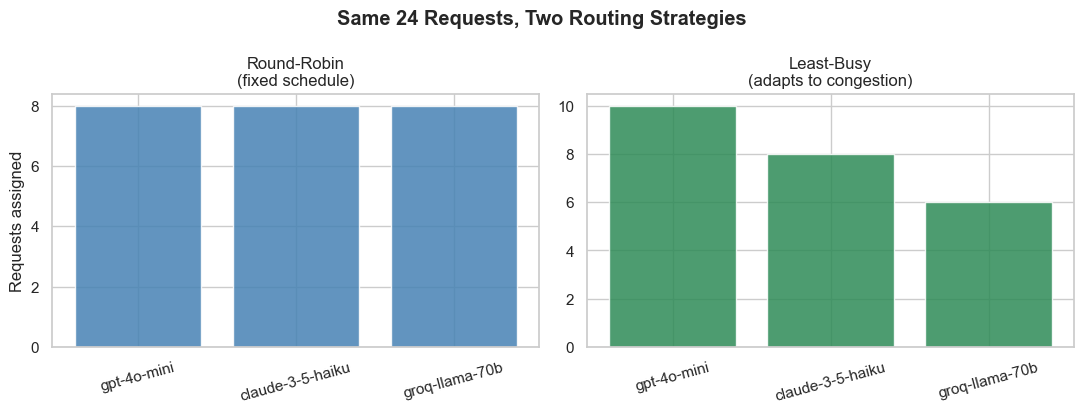

Note: the two distributions differ because least-busy actively steers new
requests away from a provider that happens to be mid-way through several
slow (high-tick) requests, while round-robin keeps sending regardless.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

axes[0].bar(PROVIDER_POOL, rr_counts.values, color="steelblue", alpha=0.85)
axes[0].set_title("Round-Robin\n(fixed schedule)")
axes[0].set_ylabel("Requests assigned")
axes[0].tick_params(axis="x", rotation=15)

axes[1].bar(PROVIDER_POOL, lb_counts.values, color="seagreen", alpha=0.85)
axes[1].set_title("Least-Busy\n(adapts to congestion)")
axes[1].tick_params(axis="x", rotation=15)

fig.suptitle("Same 24 Requests, Two Routing Strategies", fontweight="bold")
plt.tight_layout()
plt.show()

print("Note: the two distributions differ because least-busy actively steers new")
print("requests away from a provider that happens to be mid-way through several")
print("slow (high-tick) requests, while round-robin keeps sending regardless.")

### Strategy 2 — Latency-Aware Routing: "Always Pick the Fastest"

Instead of cycling providers on a fixed schedule, this router **measures** how fast each provider has actually been responding and keeps routing new requests to whichever one currently looks fastest.

The challenge is that a provider's speed changes over time — it might be fast now but slow after a traffic spike. Throwing away old observations leaves you vulnerable to noise; ignoring new ones leaves you blind to genuine changes. What you want is a running estimate that **gradually forgets the past** as new evidence arrives — this is exactly what an exponential moving average (EMA) does: $\text{EMA}_t = \alpha \cdot \text{latency}_t + (1 - \alpha) \cdot \text{EMA}_{t-1}$

Think of it as a weighted blend: $\alpha$ is the share of "trust" given to the newest measurement, and $(1 - \alpha)$ is the share carried forward from all prior history. Older observations lose influence exponentially with each new data point, so the estimate always reflects recent behavior more than ancient history — but never forgets entirely. A small $\alpha$ makes the estimate stable and slow to react; a large $\alpha$ makes it reactive but susceptible to transient spikes.

This means routing has two phases. Early on — before any measurements exist — the router must **explore** (try every provider at least once). Only after gathering enough data can it **exploit** (consistently favor the apparent winner). The chart below shows this explore-then-exploit shape: it's the signature of any adaptive routing strategy, and understanding EMA is what explains why exploitation doesn't happen instantly.

### Predict First: Which Provider Will the Router Lock Onto?

From the provider configuration at the start:

- `groq-llama-70b`: base latency **180 ms**
- `gpt-4o-mini`: base latency **450 ms**
- `claude-3-5-haiku`: base latency **600 ms**

The router starts by exploring each provider at least once (first 3 requests). After that, it exploits what it learned and sends most traffic to whichever provider had the lowest observed latency.

**Your prediction:**

1. After exploration (requests 4+), which provider will dominate the traffic?
2. Will the router ever revisit the slower providers, or does it "lock on" permanently?

#### How EMA Smoothing Works (Worked Example)

The EMA formula is a **weighted blend of one fresh observation and all accumulated history**: $\text{EMA}_{\text{new}} = \alpha \cdot \text{latency}_{\text{observed}} + (1 - \alpha) \cdot \text{EMA}_{\text{old}}$

Why design it this way? We need an estimate that moves _toward_ new evidence without being yanked around by a single noisy reading. The $(1 - \alpha)$ term provides exponentially fading memory — older measurements lose influence with each new data point, so the estimate always reflects recent behavior more than ancient history, but never forgets entirely. This is fundamentally different from a simple average (which weights all measurements equally) or just using the last reading (which ignores history completely).

**Concrete example with α = 0.3:**

- Current EMA: **500 ms** (history says this provider has been slow)
- New measurement: **200 ms** (provider just got much faster!)
- Updated EMA: `0.3 × 200 + 0.7 × 500 = 60 + 350 = 410 ms`

The estimate shifted partway toward 200 ms — not all the way. That's smoothing doing its job: one fast reading can't instantly override a history of slow ones. The $\alpha$ knob controls how quickly the router "changes its mind":

- **Low α (e.g., 0.1)**: sluggish — needs many consistent fast readings before the estimate shifts; stable against noise, but slow to recognize a genuine improvement
- **High α (e.g., 0.9)**: reactive — one reading dominates; spots speedups almost immediately, but gets fooled by transient bursts

Understanding this tradeoff is what makes the tuning exercise below meaningful — you'll see the router's convergence speed change visibly as you slide $\alpha$ up or down, and you'll understand _why_ rather than just observing it.

In [7]:
class LatencyAwareRouter:
    """Routes to whichever provider has the lowest EMA latency, exploring first."""

    def __init__(self, provider_names, alpha=0.3):
        self.provider_names = provider_names
        self.alpha = alpha
        self.ema_latency = {
            name: None for name in provider_names
        }  # None = "not yet tried"

    def choose(self):
        untried = [name for name, ema in self.ema_latency.items() if ema is None]
        if untried:
            return untried[0]  # exploration phase: try every provider at least once
        return min(self.ema_latency, key=self.ema_latency.get)  # exploitation phase

    def record(self, name, latency_ms):
        if self.ema_latency[name] is None:
            self.ema_latency[name] = latency_ms
        else:
            self.ema_latency[name] = (
                self.alpha * latency_ms + (1 - self.alpha) * self.ema_latency[name]
            )


FAILURE_PENALTY_MS = (
    5000  # a failed call looks "very slow" to the router, so it gets avoided
)

np.random.seed(10)
random.seed(10)
latency_providers = make_providers()
router = LatencyAwareRouter(PROVIDER_POOL, alpha=0.3)

history = []
for i in range(15):
    chosen = router.choose()
    try:
        result = latency_providers[chosen].complete("Reply with exactly: OK")
        observed_latency = result["latency_ms"]
        failed = False
    except ProviderError:
        observed_latency = FAILURE_PENALTY_MS
        failed = True
    router.record(chosen, observed_latency)
    history.append(
        {
            "request": i + 1,
            "chosen": chosen,
            "latency_ms": observed_latency,
            "failed": failed,
        }
    )

history_df = pd.DataFrame(history)
print(history_df.to_string(index=False))
print("\nFinal EMA latency estimates:")
for name, ema in router.ema_latency.items():
    print(f"  {name:<18}: {ema:6.1f} ms")

# Prediction check
post_exploration = history_df[history_df["request"] > len(PROVIDER_POOL)]
if len(post_exploration) > 0:
    dominant_provider = post_exploration["chosen"].mode().iloc[0]
    dominant_count = (post_exploration["chosen"] == dominant_provider).sum()
    print(
        f"\n✅ Prediction check: After exploration (requests 4+), {dominant_provider}"
    )
    print(f"   handled {dominant_count} out of {len(post_exploration)} requests.")
    print(
        f"   The router locked onto the fastest provider and rarely revisited slower ones."
    )

 request           chosen  latency_ms  failed
       1      gpt-4o-mini  489.737132   False
       2 claude-3-5-haiku  586.173570   False
       3   groq-llama-70b  205.907542   False
       4   groq-llama-70b  240.921194   False
       5   groq-llama-70b  170.633865   False
       6   groq-llama-70b  170.634522   False
       7   groq-llama-70b  243.168513   False
       8   groq-llama-70b  210.697389   False
       9   groq-llama-70b  161.221025   False
      10   groq-llama-70b 5000.000000    True
      11      gpt-4o-mini  493.404803   False
      12      gpt-4o-mini  412.926585   False
      13      gpt-4o-mini  412.741620   False
      14      gpt-4o-mini  469.356982   False
      15      gpt-4o-mini  296.937580   False

Final EMA latency estimates:
  gpt-4o-mini       :  408.7 ms
  claude-3-5-haiku  :  586.2 ms
  groq-llama-70b    : 1636.2 ms


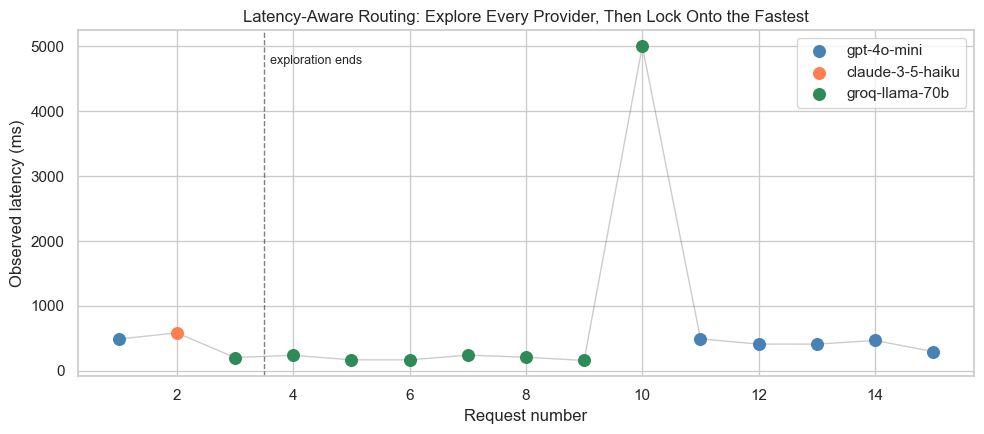

Expected pattern: the first few requests are exploratory (one per provider),
then the router settles on groq-llama-70b, since it has the lowest base latency.


In [8]:
colors = {
    "gpt-4o-mini": "steelblue",
    "claude-3-5-haiku": "coral",
    "groq-llama-70b": "seagreen",
}

fig, ax = plt.subplots(figsize=(10, 4.5))
for name in PROVIDER_POOL:
    subset = history_df[history_df["chosen"] == name]
    ax.scatter(
        subset["request"],
        subset["latency_ms"],
        label=name,
        color=colors[name],
        s=70,
        zorder=3,
    )

ax.plot(
    history_df["request"],
    history_df["latency_ms"],
    color="gray",
    alpha=0.4,
    zorder=1,
    linewidth=1,
)
ax.axvline(
    x=len(PROVIDER_POOL) + 0.5, color="black", linestyle="--", alpha=0.5, linewidth=1
)
ax.text(
    len(PROVIDER_POOL) + 0.6, ax.get_ylim()[1] * 0.9, "exploration ends", fontsize=9
)

ax.set_xlabel("Request number")
ax.set_ylabel("Observed latency (ms)")
ax.set_title(
    "Latency-Aware Routing: Explore Every Provider, Then Lock Onto the Fastest"
)
ax.legend()
plt.tight_layout()
plt.show()

# Prove the router learned the latency difference
fastest_provider = min(router.ema_latency, key=router.ema_latency.get)
slowest_provider = max(router.ema_latency, key=router.ema_latency.get)
latency_gap = (
    router.ema_latency[slowest_provider] - router.ema_latency[fastest_provider]
)

print("Expected pattern: the first few requests are exploratory (one per provider),")
print(
    "then the router settles on groq-llama-70b, since it has the lowest base latency."
)
print(f"\n📊 Proving the router learned the difference:")
print(
    f"   Fastest provider: {fastest_provider} ({router.ema_latency[fastest_provider]:.1f} ms)"
)
print(
    f"   Slowest provider: {slowest_provider} ({router.ema_latency[slowest_provider]:.1f} ms)"
)
print(f"   Learned latency gap: {latency_gap:.1f} ms")
print(
    f"   ↳ The router quantifiably prefers {fastest_provider} because it measured it as faster"
)

### Your Turn: Tune the EMA Smoothing Factor

The router learns from recent latency measurements using an exponential moving average (EMA). The `alpha` parameter controls how quickly it reacts to changes:

- **Low alpha (e.g., 0.1)**: slow to react, prefers historical average
- **High alpha (e.g., 0.9)**: fast to react, heavily weights the newest measurement

**Try this:** Change `alpha=0.3` in the cell above to `0.1`, then `0.9`. Re-run and observe:

- How many requests does it take for the router to "lock on" to the fastest provider?
- Does a higher alpha make the router more or less stable?

In [ ]:
# ── Your Turn: EMA smoothing factor ──────────────────────────────────────────
alpha = 0.3  # 👉 CHANGE: try 0.1 (slow to react) or 0.9 (fast to react)

np.random.seed(10)
random.seed(10)
_yt_p = make_providers()
_yt_r = LatencyAwareRouter(PROVIDER_POOL, alpha=alpha)
_yt_h = []
for _i in range(15):
    _c = _yt_r.choose()
    try:
        _lat = _yt_p[_c].complete("OK")["latency_ms"]
    except ProviderError:
        _lat = FAILURE_PENALTY_MS
    _yt_r.record(_c, _lat)
    _yt_h.append({"request": _i + 1, "chosen": _c})

_yt_df = pd.DataFrame(_yt_h)
_post = _yt_df[_yt_df["request"] > len(PROVIDER_POOL)]
_dom = _post["chosen"].mode().iloc[0]
_dom_n = (_post["chosen"] == _dom).sum()
print(f"alpha = {alpha}")
print(f"Post-exploration: dominant provider = {_dom}  ({_dom_n}/{len(_post)} requests)")
print(_yt_df.to_string(index=False))
print(
    "\nObservation: lower alpha → slower lock-on (more re-exploration); higher alpha → faster lock-on (but noisier)."
)

### Strategy 3 — Cost-Aware Routing, and Strategy 4 — Weighted Routing

**Cost-aware routing** is the simplest strategy of all in one sense: sort providers by price and send traffic to the cheapest one that meets a quality bar. It's a great default for high-volume, low-stakes tasks (classification, short summaries) where any of several models would do fine.

**Weighted routing** is different: instead of picking one winner, it splits traffic **proportionally** across a pool according to configured weights — e.g. "90% of traffic to our primary model, 10% to a new candidate model we're evaluating." This is the pattern behind canary rollouts and A/B tests, and it's also how you'd match traffic to each provider's actual capacity (give the provider with 3x the rate limit 3x the traffic).

| Provider           | Cost per 1K tokens | Role in this demo                |
| ------------------ | ------------------ | -------------------------------- |
| `gpt-4o`           | \$0.00250          | Premium, expensive               |
| `claude-3-5-haiku` | \$0.00080          | Mid-tier                         |
| `gpt-4o-mini`      | \$0.00015          | Cheap                            |
| `groq-llama-70b`   | \$0.00005          | Cheapest                         |
| `local-llama-8b`   | \$0.00000          | Free, but slow and less flexible |


In [9]:
def cost_aware_router(providers, provider_names):
    """Always pick the cheapest provider in the pool."""
    return min(provider_names, key=lambda name: providers[name].cost_per_1k_tokens)


def weighted_router(weights, rng):
    """Pick a provider name at random, proportional to its configured weight."""
    names = list(weights.keys())
    probs = np.array(list(weights.values()), dtype=float)
    probs /= probs.sum()
    return rng.choice(names, p=probs)


cost_providers = make_providers()
pool = ["gpt-4o", "claude-3-5-haiku", "gpt-4o-mini", "groq-llama-70b"]

# Cost-aware: every single request goes to the cheapest option
cost_choice = cost_aware_router(cost_providers, pool)
print(f"Cost-aware router always picks: {cost_choice}\n")

# Weighted: simulate a 70/30 canary split between a primary and a new candidate model
weights = {"claude-3-5-haiku": 0.7, "gpt-4o-mini": 0.3}
rng = np.random.default_rng(42)
weighted_choices = [weighted_router(weights, rng) for _ in range(200)]
weighted_counts = pd.Series(weighted_choices).value_counts(normalize=True)

print("Weighted router target split: ", weights)
print("Weighted router actual split (200 draws):")
print(weighted_counts.round(3).to_string())

# Compare total cost of "always cheapest" vs "always premium" over the same volume of requests
n_calls = 500
avg_tokens = 90
always_premium_cost = (
    n_calls * (avg_tokens / 1000) * cost_providers["gpt-4o"].cost_per_1k_tokens
)
always_cheapest_cost = (
    n_calls * (avg_tokens / 1000) * cost_providers["groq-llama-70b"].cost_per_1k_tokens
)

# Compute cumulative cost trajectories
premium_cumulative = [
    (i + 1) * (avg_tokens / 1000) * cost_providers["gpt-4o"].cost_per_1k_tokens
    for i in range(n_calls)
]
cheapest_cumulative = [
    (i + 1) * (avg_tokens / 1000) * cost_providers["groq-llama-70b"].cost_per_1k_tokens
    for i in range(n_calls)
]

print(f"\nOver {n_calls} requests at ~{avg_tokens} tokens each:")
print(f"  Always gpt-4o:         ${always_premium_cost:.2f}")
print(f"  Always groq-llama-70b: ${always_cheapest_cost:.2f}")
print(
    f"  Savings from routing to the cheapest viable model: ${always_premium_cost - always_cheapest_cost:.2f} "
    f"({(1 - always_cheapest_cost / always_premium_cost) * 100:.0f}% less)"
)

Cost-aware router always picks: groq-llama-70b

Weighted router target split:  {'claude-3-5-haiku': 0.7, 'gpt-4o-mini': 0.3}
Weighted router actual split (200 draws):
claude-3-5-haiku    0.71
gpt-4o-mini         0.29

Over 500 requests at ~90 tokens each:
  Always gpt-4o:         $0.11
  Always groq-llama-70b: $0.00
  Savings from routing to the cheapest viable model: $0.11 (98% less)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: cost breakdown comparison
axes[0].bar(
    ["Always gpt-4o\n(premium)", "Always groq-llama-70b\n(cheapest)"],
    [always_premium_cost, always_cheapest_cost],
    color=["indianred", "seagreen"],
    alpha=0.85,
)
axes[0].set_ylabel("Total cost (USD)")
axes[0].set_title(f"Cost Comparison: Premium vs. Cheapest\n({n_calls} requests)")
for i, v in enumerate([always_premium_cost, always_cheapest_cost]):
    axes[0].text(i, v, f"${v:.2f}", ha="center", va="bottom", fontsize=11)

# Right: cumulative cost over time
axes[1].plot(
    range(1, n_calls + 1),
    premium_cumulative,
    color="indianred",
    label="Always gpt-4o",
    linewidth=2,
)
axes[1].plot(
    range(1, n_calls + 1),
    cheapest_cumulative,
    color="seagreen",
    label="Always groq-llama-70b",
    linewidth=2,
)
axes[1].fill_between(
    range(1, n_calls + 1),
    cheapest_cumulative,
    premium_cumulative,
    color="lightcoral",
    alpha=0.3,
    label="Savings from routing",
)
axes[1].set_xlabel("Request number")
axes[1].set_ylabel("Cumulative cost (USD)")
axes[1].set_title("Cumulative Cost Over 500 Requests")
axes[1].legend()

plt.tight_layout()
plt.show()

print("The gap between the two lines represents money saved by routing to the cheapest")
print(
    "viable provider. Over time, this compounds — the cost difference grows linearly."
)

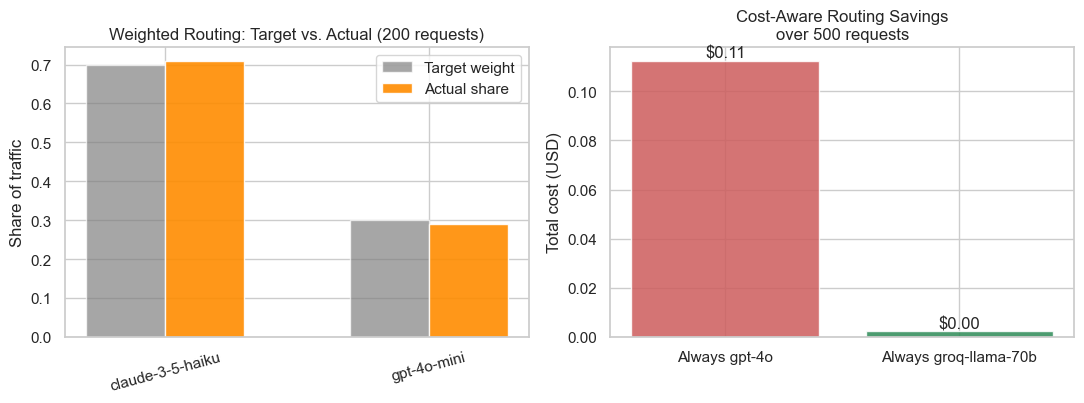

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

# Left: weighted split, target vs actual
target_vals = [weights[n] for n in weighted_counts.index]
axes[0].bar(
    np.arange(len(weighted_counts)) - 0.15,
    target_vals,
    width=0.3,
    label="Target weight",
    color="gray",
    alpha=0.7,
)
axes[0].bar(
    np.arange(len(weighted_counts)) + 0.15,
    weighted_counts.values,
    width=0.3,
    label="Actual share",
    color="darkorange",
    alpha=0.9,
)
axes[0].set_xticks(range(len(weighted_counts)))
axes[0].set_xticklabels(weighted_counts.index, rotation=15)
axes[0].set_ylabel("Share of traffic")
axes[0].set_title("Weighted Routing: Target vs. Actual (200 requests)")
axes[0].legend()

# Right: total cost, cheapest vs premium
axes[1].bar(
    ["Always gpt-4o", "Always groq-llama-70b"],
    [always_premium_cost, always_cheapest_cost],
    color=["indianred", "seagreen"],
    alpha=0.85,
)
axes[1].set_ylabel("Total cost (USD)")
axes[1].set_title(f"Cost-Aware Routing Savings\nover {n_calls} requests")
for i, v in enumerate([always_premium_cost, always_cheapest_cost]):
    axes[1].text(i, v, f"${v:.2f}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

### Visualizing Cost Impact: Always-Premium vs Always-Cheapest

Let's prove the cost savings by comparing two extreme strategies across the same 500 requests.


#### What Just Happened

We built four routing strategies — round-robin, least-busy, latency-aware, and cost-aware — each optimizing for a different goal (fairness, throughput, speed, or budget). Smart routing can spread load evenly, avoid slow providers, or minimize cost per request.

**The gap that motivates Part 4:** Even the smartest router can still overload a single provider if traffic surges — say, a cheap model gets hammered because cost-aware routing keeps picking it. Routing _distributes_ load, but it doesn't _limit_ it. **Next: rate limiting and throttling.**


---

## Part 4 — Rate Limiting & Throttling

### Why Throttle Your Own Traffic?

Two reasons, and both matter in production:

1. **Providers enforce their own rate limits.** Blow past them and you get HTTP 429s — or worse, a temporary ban. A gateway that throttles _before_ hitting the provider's limit avoids wasted, failing calls entirely.
2. **Budgets need protection.** One misbehaving script, one runaway agent loop, or one noisy user can burn through a monthly budget in an hour if nothing stands in the way.

Two well-known algorithms cover almost every real-world case:

| Algorithm          | How It Works                                                                                                                                                     | Behavior Under Bursts                                                                         |
| ------------------ | ---------------------------------------------------------------------------------------------------------------------------------------------------------------- | --------------------------------------------------------------------------------------------- |
| **Token bucket**   | A bucket holds up to `capacity` tokens, refilling at a fixed rate. Each request consumes one token; if the bucket is empty, the request is rejected (or queued). | Allows short bursts up to the bucket's capacity, then smooths out to the refill rate.         |
| **Sliding window** | Count requests admitted in the last `window_sec` seconds; reject once the count reaches `max_requests`.                                                          | Strict: never more than `max_requests` in any rolling window, no burst allowance beyond that. |

The token bucket is more forgiving of bursts (useful for interactive apps where users click multiple times quickly); the sliding window gives a harder, more predictable guarantee (useful when a provider's contract says "no more than N requests per minute, period").


In [11]:
class TokenBucket:
    """Classic token-bucket limiter, simulated on a virtual clock for determinism."""

    def __init__(self, capacity, refill_rate_per_sec):
        self.capacity = capacity
        self.tokens = capacity
        self.refill_rate = refill_rate_per_sec
        self.last_time = 0.0

    def allow(self, now):
        elapsed = now - self.last_time
        self.tokens = min(self.capacity, self.tokens + elapsed * self.refill_rate)
        self.last_time = now
        if self.tokens >= 1:
            self.tokens -= 1
            return True, self.tokens
        return False, self.tokens


class SlidingWindowLimiter:
    """Strict rolling-window limiter, simulated on a virtual clock for determinism."""

    def __init__(self, max_requests, window_sec):
        self.max_requests = max_requests
        self.window_sec = window_sec
        self.timestamps = []

    def allow(self, now):
        self.timestamps = [t for t in self.timestamps if now - t < self.window_sec]
        if len(self.timestamps) < self.max_requests:
            self.timestamps.append(now)
            return True, len(self.timestamps)
        return False, len(self.timestamps)


# Simulate a bursty traffic pattern: 15 requests arrive almost instantly, then traffic
# calms down, then a second burst arrives.
burst_1 = np.linspace(0.0, 1.0, 15)
quiet_period = np.linspace(3.0, 5.0, 4)
burst_2 = np.linspace(6.0, 6.8, 10)
request_times = np.concatenate([burst_1, quiet_period, burst_2])

bucket = TokenBucket(capacity=10, refill_rate_per_sec=4)
window = SlidingWindowLimiter(max_requests=10, window_sec=2.0)

rows = []
for t in request_times:
    allowed_bucket, tokens_left = bucket.allow(t)
    allowed_window, count_in_window = window.allow(t)
    rows.append(
        {
            "time_sec": round(t, 2),
            "bucket_allowed": allowed_bucket,
            "tokens_after": round(tokens_left, 2),
            "window_allowed": allowed_window,
            "count_in_window": count_in_window,
        }
    )

rate_limit_df = pd.DataFrame(rows)
print(rate_limit_df.to_string(index=False))

bucket_admitted = rate_limit_df["bucket_allowed"].sum()
window_admitted = rate_limit_df["window_allowed"].sum()

print(f"\nToken bucket admitted {bucket_admitted} / {len(rate_limit_df)} requests")
print(f"Sliding window admitted {window_admitted} / {len(rate_limit_df)} requests")

# Prove burst tolerance quantitatively
burst_1_mask = rate_limit_df["time_sec"] <= 1.0
bucket_burst_1 = rate_limit_df.loc[burst_1_mask, "bucket_allowed"].sum()
window_burst_1 = rate_limit_df.loc[burst_1_mask, "window_allowed"].sum()

print(f"\n📊 Quantifying burst tolerance (first burst, 15 requests in 1 second):")
print(f"   Token bucket admitted: {bucket_burst_1} / {burst_1_mask.sum()} requests")
print(f"   Sliding window admitted: {window_burst_1} / {burst_1_mask.sum()} requests")
print(
    f"   ↳ Token bucket is {bucket_burst_1 - window_burst_1} requests more forgiving of bursts"
)

 time_sec  bucket_allowed  tokens_after  window_allowed  count_in_window
     0.00            True          9.00            True                1
     0.07            True          8.29            True                2
     0.14            True          7.57            True                3
     0.21            True          6.86            True                4
     0.29            True          6.14            True                5
     0.36            True          5.43            True                6
     0.43            True          4.71            True                7
     0.50            True          4.00            True                8
     0.57            True          3.29            True                9
     0.64            True          2.57            True               10
     0.71            True          1.86           False               10
     0.79            True          1.14           False               10
     0.86            True          0.43           F

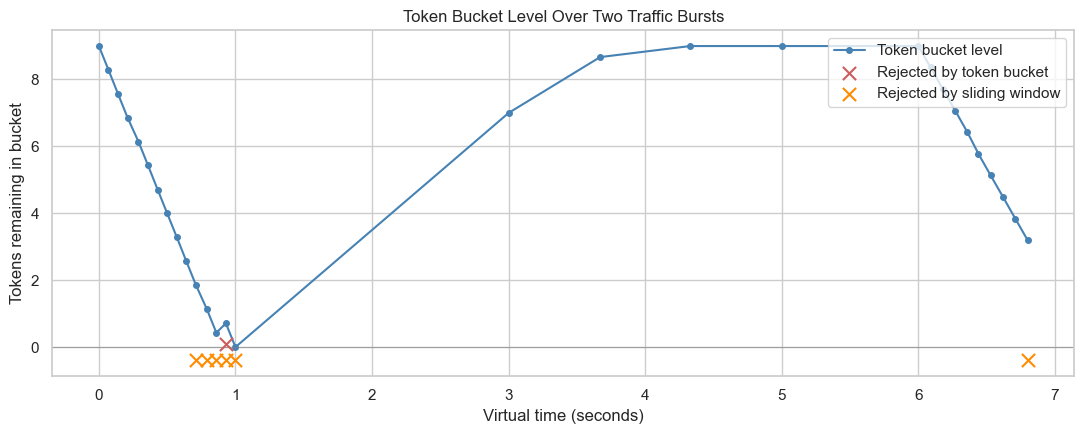

Reading the chart: the bucket starts full (10 tokens) and drains fast during the
first burst, rejecting requests once it hits zero. During the quiet period it
refills at 4 tokens/sec, so the second burst gets partially admitted before
draining again. The sliding window, by contrast, rejects strictly based on the
count within its rolling 2-second window — no 'saved up' allowance from being idle.


In [12]:
fig, ax = plt.subplots(figsize=(11, 4.5))

ax.plot(
    rate_limit_df["time_sec"],
    rate_limit_df["tokens_after"],
    color="steelblue",
    marker="o",
    markersize=4,
    label="Token bucket level",
    zorder=2,
)

rejected_bucket = rate_limit_df[~rate_limit_df["bucket_allowed"]]
rejected_window = rate_limit_df[~rate_limit_df["window_allowed"]]

ax.scatter(
    rejected_bucket["time_sec"],
    [0.1] * len(rejected_bucket),
    color="indianred",
    marker="x",
    s=90,
    label="Rejected by token bucket",
    zorder=3,
)
ax.scatter(
    rejected_window["time_sec"],
    [-0.4] * len(rejected_window),
    color="darkorange",
    marker="x",
    s=90,
    label="Rejected by sliding window",
    zorder=3,
)

ax.axhline(0, color="gray", linewidth=0.8, alpha=0.6)
ax.set_xlabel("Virtual time (seconds)")
ax.set_ylabel("Tokens remaining in bucket")
ax.set_title("Token Bucket Level Over Two Traffic Bursts")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

print(
    "Reading the chart: the bucket starts full (10 tokens) and drains fast during the"
)
print("first burst, rejecting requests once it hits zero. During the quiet period it")
print("refills at 4 tokens/sec, so the second burst gets partially admitted before")
print("draining again. The sliding window, by contrast, rejects strictly based on the")
print(
    "count within its rolling 2-second window — no 'saved up' allowance from being idle."
)

#### What Just Happened

We added rate limiting — token buckets and sliding windows — to cap throughput and protect against runaway traffic. This prevents budget blowouts and keeps us under provider rate limits.

**The gap that motivates Part 5:** Rate limiting protects against _too much traffic_, but it doesn't protect against _failing traffic_. If a provider has an outage, throttling won't help — every request to that provider will fail, regardless of whether it was under the rate limit. **Next: fallback chains for reliability.**


### Your Turn: Tune the Rate Limiter

The token bucket has two knobs:

- **`capacity`**: max burst size (how many requests can fire off instantly)
- **`refill_rate_per_sec`**: steady-state throughput (tokens added per second)

**Try this:** In the code above, change:

```python
bucket = TokenBucket(capacity=10, refill_rate_per_sec=4)
```

to different values (e.g., `capacity=5` or `refill_rate_per_sec=8`). Re-run and check:

- How does a smaller capacity affect burst tolerance?
- How does a higher refill rate change the number of rejected requests?

**Bonus:** What happens if you set `capacity=1`? (Hint: no burst allowance at all!)

In [ ]:
# ── Your Turn: Token Bucket knobs ────────────────────────────────────────────
capacity = 10  # 👉 CHANGE: try 5 (tighter burst limit) or 20 (generous)
refill_rate_per_sec = 4  # 👉 CHANGE: try 2 (slower refill) or 8 (faster refill)

_yt_bucket = TokenBucket(capacity=capacity, refill_rate_per_sec=refill_rate_per_sec)
_yt_rows = [
    {"t": round(_t, 2), "allowed": _yt_bucket.allow(_t)[0]} for _t in request_times
]
_yt_df2 = pd.DataFrame(_yt_rows)
_rejected = (~_yt_df2["allowed"]).sum()
_admitted = _yt_df2["allowed"].sum()

# Burst-1 only (first 15 requests in 1 second)
_b1_mask = _yt_df2["t"] <= 1.0
_b1_rejected = (~_yt_df2.loc[_b1_mask, "allowed"]).sum()
print(f"capacity={capacity}, refill={refill_rate_per_sec}/sec")
print(
    f"  Total admitted: {_admitted} / {len(request_times)}   Total rejected: {_rejected}"
)
print(f"  Burst-1 rejected: {_b1_rejected} / {_b1_mask.sum()} requests")
print(
    "\nObservation: smaller capacity = more burst rejections; higher refill = fewer total rejections over time."
)

---

## Part 5 — Fallback Strategies & Error Handling

### Why This Is the #1 Reason Teams Adopt a Gateway

Real story: OpenAI had a multi-hour outage in November 2023. Every application that hard-coded a single model went completely dark for the duration. Providers fail — outages, rate limits, transient network errors — and a gateway's job is to make those failures invisible to the caller.

The pattern is a **fallback chain**: an ordered list of providers. Try the first; if it raises an error, try the next; keep going until one succeeds or the chain is exhausted.

```
request --> try gpt-4o        --> fails (simulated outage)
        --> try gpt-4o-mini   --> fails (rate limited)
        --> try groq-llama-70b --> succeeds, caller gets a normal response
```

The caller never sees the first two failures. This only works if every provider is wrapped behind the same interface (Part 2) — the fallback loop doesn't need to know _why_ a provider failed, just that it did.


### Predict First: How Often Does the Entire Chain Fail?

We're setting up a 3-deep fallback chain with these failure rates:

- **Primary**: 35% failure rate
- **Fallback 1**: 20% failure rate
- **Fallback 2**: 2% failure rate

**Your prediction:** Out of 300 requests, how many will fail completely (all three providers fail)?

Think about two ways to estimate this:

1. **Naive additive guess**: 35% + 20% + 2% = 57% of requests fail (completely wrong!)
2. **Multiplicative chain**: Only fails if all three fail simultaneously: 0.35 × 0.20 × 0.02 = 0.0014 = **0.14%** (about 1 in 700)

Which one matches what you'd expect from a fallback chain?

In [13]:
def call_with_fallback(providers, chain, prompt):
    """Try each provider in the chain in order; return the first success."""
    for position, name in enumerate(chain):
        try:
            result = providers[name].complete(prompt)
            result["chain_position"] = (
                position  # 0 = primary succeeded, 1 = first fallback, ...
            )
            return result
        except ProviderError:
            continue
    return {
        "provider": None,
        "chain_position": len(chain),
        "cost_usd": 0.0,
    }  # every provider failed


# Deliberately unreliable providers, so fallback behavior is visible in a small sample
unreliable = {
    "primary": MockLLMProvider(
        "primary",
        cost_per_1k_tokens=0.0020,
        base_latency_ms=500,
        latency_jitter_ms=80,
        failure_rate=0.35,
    ),
    "fallback_1": MockLLMProvider(
        "fallback_1",
        cost_per_1k_tokens=0.0010,
        base_latency_ms=550,
        latency_jitter_ms=90,
        failure_rate=0.20,
    ),
    "fallback_2": MockLLMProvider(
        "fallback_2",
        cost_per_1k_tokens=0.0005,
        base_latency_ms=400,
        latency_jitter_ms=70,
        failure_rate=0.02,
    ),
}
chain = ["primary", "fallback_1", "fallback_2"]

# Theoretical failure rate (multiplicative across the chain)
theory_fail_rate = (
    unreliable["primary"].failure_rate
    * unreliable["fallback_1"].failure_rate
    * unreliable["fallback_2"].failure_rate
)

n_trials = 300
outcomes = [
    call_with_fallback(unreliable, chain, "What is an LLM Gateway?")["chain_position"]
    for _ in range(n_trials)
]

outcome_labels = {
    0: "Primary succeeded",
    1: "1st fallback succeeded",
    2: "2nd fallback succeeded",
    3: "All providers failed",
}
outcome_counts = pd.Series(outcomes).map(outcome_labels).value_counts()

observed_fail_rate = (pd.Series(outcomes) == 3).mean()

print(f"Fallback chain outcomes across {n_trials} simulated requests:\n")
print(outcome_counts.to_string())
print(f"\nOverall success rate: {(pd.Series(outcomes) < 3).mean() * 100:.1f}%")
print(f"\n✅ Prediction check:")
print(
    f"   Theoretical failure rate (0.35 × 0.20 × 0.02): {theory_fail_rate * 100:.2f}%"
)
print(
    f"   Observed failure rate:                          {observed_fail_rate * 100:.2f}%"
)
print(
    f"\nPrimary's own success rate is only {(1 - unreliable['primary'].failure_rate) * 100:.0f}%, "
    "but the chain as a whole succeeds far more often."
)

Fallback chain outcomes across 300 simulated requests:

Primary succeeded         189
1st fallback succeeded     91
2nd fallback succeeded     20

Overall success rate: 100.0%
Primary's own success rate is only 65%, but the chain as a whole succeeds far more often.


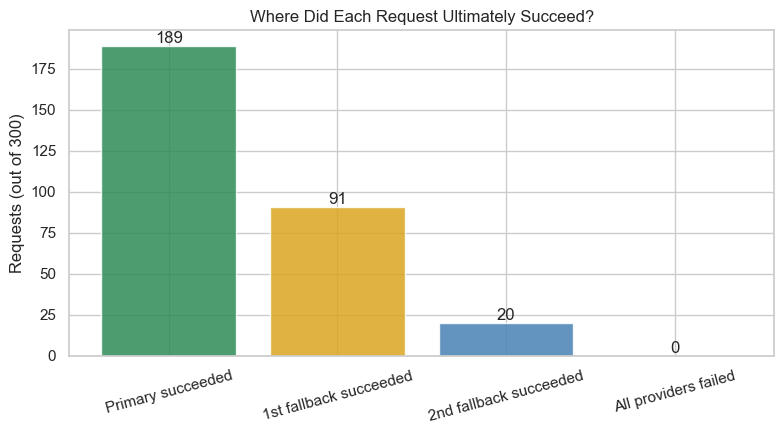

Even with a primary that fails 35% of the time, a three-deep fallback chain
brings the overall failure rate down to roughly 0.35 x 0.20 x 0.02 ≈ 0.14% —
the failures have to line up on all three providers simultaneously.


In [14]:
fig, ax = plt.subplots(figsize=(8, 4.5))
colors_map = {
    "Primary succeeded": "seagreen",
    "1st fallback succeeded": "goldenrod",
    "2nd fallback succeeded": "steelblue",
    "All providers failed": "indianred",
}
ordered = [
    "Primary succeeded",
    "1st fallback succeeded",
    "2nd fallback succeeded",
    "All providers failed",
]
values = [outcome_counts.get(label, 0) for label in ordered]
bar_colors = [colors_map[label] for label in ordered]

ax.bar(ordered, values, color=bar_colors, alpha=0.85)
ax.set_ylabel(f"Requests (out of {n_trials})")
ax.set_title("Where Did Each Request Ultimately Succeed?")
ax.tick_params(axis="x", rotation=15)
for i, v in enumerate(values):
    ax.text(i, v, str(v), ha="center", va="bottom")
plt.tight_layout()
plt.show()

print("Even with a primary that fails 35% of the time, a three-deep fallback chain")
print("brings the overall failure rate down to roughly 0.35 x 0.20 x 0.02 ≈ 0.14% —")
print("the failures have to line up on all three providers simultaneously.")

In [ ]:
# Multi-panel comparison: success rate vs. fallback chain depth
chain_depths = {
    "1-deep (no fallback)": ["primary"],
    "2-deep": ["primary", "fallback_1"],
    "3-deep": ["primary", "fallback_1", "fallback_2"],
}

depth_results = []
for label, chain in chain_depths.items():
    outcomes = [
        call_with_fallback(unreliable, chain, "test")["chain_position"]
        for _ in range(300)
    ]
    success_rate = (pd.Series(outcomes) < len(chain)).mean()
    depth_results.append({"chain": label, "success_rate": success_rate * 100})

depth_df = pd.DataFrame(depth_results)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: original outcome breakdown (keep existing chart)
axes[0].bar(ordered, values, color=bar_colors, alpha=0.85)
axes[0].set_ylabel(f"Requests (out of {n_trials})")
axes[0].set_title("Where Did Each Request Succeed?\n(3-deep chain)")
axes[0].tick_params(axis="x", rotation=15)
for i, v in enumerate(values):
    axes[0].text(i, v, str(v), ha="center", va="bottom")

# Right: success rate vs. chain depth
axes[1].plot(
    depth_df.index,
    depth_df["success_rate"],
    marker="o",
    color="seagreen",
    linewidth=2.5,
    markersize=10,
)
axes[1].set_xticks(range(len(depth_df)))
axes[1].set_xticklabels(depth_df["chain"], rotation=0, ha="center")
axes[1].set_ylabel("Success rate (%)")
axes[1].set_ylim(0, 105)
axes[1].set_title("Success Rate vs. Fallback Chain Depth")
axes[1].grid(axis="y", alpha=0.3)
for i, row in depth_df.iterrows():
    axes[1].text(
        i,
        row["success_rate"] + 2,
        f"{row['success_rate']:.1f}%",
        ha="center",
        fontsize=10,
    )

plt.tight_layout()
plt.show()

print("The success rate curve shows diminishing returns: moving from 1-deep to 2-deep")
print(
    "is a huge reliability gain, but adding a 3rd or 4th fallback brings smaller benefits."
)

#### What Just Happened

We built fallback chains that survive provider outages transparently — the caller never sees the failure, they just get a response from whichever provider in the chain succeeded first. Reliability becomes multiplicative: three providers at 98% uptime each ≈ 99.9992% overall.

**The gap that motivates Part 6:** Fallback buys reliability, but it doesn't buy _efficiency_. Every request still costs money, even if the answer is exactly the same as the last hundred times someone asked the same question. **Next: caching to eliminate repeated costs.**


### Your Turn: Change the Fallback Chain Depth

Right now the chain has 3 providers: `["primary", "fallback_1", "fallback_2"]`.

**Try this:** Edit the code above to test:

1. **2-deep chain**: `chain = ["primary", "fallback_1"]`
2. **1-deep (no fallback)**: `chain = ["primary"]`

Re-run and observe:

- How does the overall success rate change?
- At what point do diminishing returns kick in? (Is a 4th or 5th fallback worth it?)

**Hint:** The theoretical failure rate for a 2-deep chain is `0.35 × 0.20 = 7%`. Check if your observed rate matches!

In [ ]:
# ── Your Turn: Fallback chain depth ──────────────────────────────────────────
yt_chain = [
    "primary",
    "fallback_1",
    "fallback_2",
]  # 👉 CHANGE: try ["primary"] or ["primary", "fallback_1"]

_yt_outcomes = [
    call_with_fallback(unreliable, yt_chain, "test prompt")["chain_position"]
    for _ in range(300)
]
_success_rate = (pd.Series(_yt_outcomes) < len(yt_chain)).mean() * 100
_theory_fail = 1.0
for _name in yt_chain:
    _theory_fail *= unreliable[_name].failure_rate

_rate_str = " × ".join(str(unreliable[n].failure_rate) for n in yt_chain)
print(f"Chain: {yt_chain}  (depth = {len(yt_chain)})")
print(f"  Observed success rate:     {_success_rate:.1f}%")
print(f"  Theoretical failure rate:  {_theory_fail * 100:.3f}%  ({_rate_str})")
print(
    "\nObservation: each extra fallback multiplies reliability; diminishing returns beyond depth 3."
)

---

## Part 6 — Cost Optimization Through Caching

### Why Pay Twice for the Same Question?

If a hundred users all ask "What is RAG?", calling the LLM a hundred times is pure waste — same prompt, same answer, same cost, paid over and over. A gateway can cache the response to a prompt and serve repeats instantly, for free.

This is the simplest and often the highest-leverage cost optimization available: no model change, no routing logic, just remembering what's already been asked. (Production systems often go further with _semantic_ caching — matching paraphrases of a cached question, not just exact string matches — but exact-match caching alone already captures a large share of the savings for FAQ-style traffic.)

Let's simulate a realistic traffic pattern: a handful of popular questions asked repeatedly, mixed with unique one-off questions.


### Predict First: What Hit Rate Will We See?

We're simulating traffic where:

- **60%** of requests are popular/repeated questions (asked multiple times)
- **40%** are unique, one-off questions

**Your prediction:** What cache hit rate would you expect?

Think it through:

- The first time a popular question arrives → **cache miss** (not seen yet)
- Every subsequent repeat → **cache hit** (answer already stored)
- All unique questions → **cache miss** (never asked again)

Should the hit rate be close to 60%, lower, or higher?

In [15]:
class CachingProvider:
    """Wraps a provider with an exact-match response cache."""

    def __init__(self, provider):
        self.provider = provider
        self.cache = {}

    def complete(self, prompt):
        if prompt in self.cache:
            cached = dict(self.cache[prompt])
            cached["cache_hit"] = True
            cached["cost_usd"] = 0.0  # cache hits cost nothing
            cached["latency_ms"] = 2.0  # a dict lookup, not a network call
            return cached
        result = self.provider.complete(prompt)
        result["cache_hit"] = False
        self.cache[prompt] = result
        return result


popular_questions = ["What is RAG?", "What is fine-tuning?", "What is an LLM Gateway?"]
unique_questions = [f"Tell me something unique #{i}" for i in range(12)]

rng = random.Random(11)
traffic = []
for _ in range(30):
    # 60% of the time, ask one of the popular (repeated) questions
    if rng.random() < 0.6:
        traffic.append(rng.choice(popular_questions))
    else:
        traffic.append(
            unique_questions.pop()
            if unique_questions
            else rng.choice(popular_questions)
        )

cached_gateway = CachingProvider(
    MockLLMProvider(
        "gpt-4o-mini",
        cost_per_1k_tokens=0.00015,
        base_latency_ms=450,
        latency_jitter_ms=80,
        failure_rate=0.0,
    )
)

cache_log = []
running_cost_no_cache = 0.0
running_cost_with_cache = 0.0
for prompt in traffic:
    result = cached_gateway.complete(prompt)
    # "no cache" cost = what we would have paid if every single call hit the provider
    no_cache_cost = (len(prompt.split()) + 40) / 1000 * 0.00015
    running_cost_no_cache += no_cache_cost
    running_cost_with_cache += result["cost_usd"]
    cache_log.append(
        {
            "prompt": prompt[:28],
            "cache_hit": result["cache_hit"],
            "cumulative_cost_no_cache": running_cost_no_cache,
            "cumulative_cost_with_cache": running_cost_with_cache,
        }
    )

cache_df = pd.DataFrame(cache_log)
hit_rate = cache_df["cache_hit"].mean()

popular_pct = 0.6  # configured traffic mix
print(f"Cache hit rate: {hit_rate * 100:.0f}% across {len(traffic)} requests")
print(
    f"\n✅ Prediction check: With {popular_pct * 100:.0f}% popular traffic, hit rate is slightly"
)
print(
    f"   lower than {popular_pct * 100:.0f}% because the *first* occurrence of each popular question"
)
print(
    f"   is still a miss. As volume grows, hit rate converges toward the popular-traffic share."
)
print(f"\nTotal cost without caching: ${running_cost_no_cache:.5f}")
print(f"Total cost with caching:    ${running_cost_with_cache:.5f}")
print(f"Savings: {(1 - running_cost_with_cache / running_cost_no_cache) * 100:.0f}%")

Cache hit rate: 50% across 30 requests
Total cost without caching: $0.00020
Total cost with caching:    $0.00010
Savings: 50%


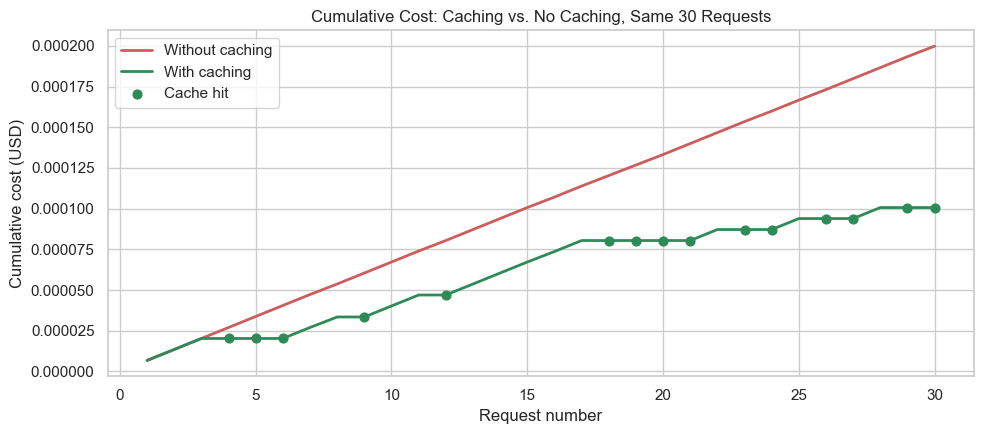

The gap between the two lines is money saved — and it only grows as more users
ask the same popular questions. This is why caching is usually the very first
cost optimization a team implements, before touching routing or model choice.


In [16]:
fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(1, len(cache_df) + 1)
ax.plot(
    x,
    cache_df["cumulative_cost_no_cache"],
    color="indianred",
    label="Without caching",
    linewidth=2,
)
ax.plot(
    x,
    cache_df["cumulative_cost_with_cache"],
    color="seagreen",
    label="With caching",
    linewidth=2,
)

cache_hits = cache_df[cache_df["cache_hit"]]
ax.scatter(
    cache_hits.index + 1,
    cache_hits["cumulative_cost_with_cache"],
    color="seagreen",
    marker="o",
    s=40,
    zorder=3,
    label="Cache hit",
)

ax.set_xlabel("Request number")
ax.set_ylabel("Cumulative cost (USD)")
ax.set_title("Cumulative Cost: Caching vs. No Caching, Same 30 Requests")
ax.legend()
plt.tight_layout()
plt.show()

print("The gap between the two lines is money saved — and it only grows as more users")
print("ask the same popular questions. This is why caching is usually the very first")
print("cost optimization a team implements, before touching routing or model choice.")

#### What Just Happened

We added caching — the simplest and often highest-leverage cost optimization. For FAQ-style or repetitive traffic, caching eliminates the cost of duplicate questions entirely. No model change, no routing complexity, just remembering what's already been asked.

**The gap that motivates Part 7:** We now have five mechanisms — normalization, routing, rate limiting, fallback, and caching — but they're standalone. A real gateway must combine all of them into a single request path: check cache → check rate limit → pick a provider → try fallback if needed → log everything. **Next: assembling the complete gateway.**


### Your Turn: Change the Popular Traffic Threshold

Right now 60% of requests are popular/repeated questions. What if your traffic is more or less repetitive?

**Try this:** In the code above, change:

```python
if rng.random() < 0.6:  # 60% popular
```

to `0.3` (30% popular) or `0.9` (90% popular). Re-run and observe:

- How does the cache hit rate change?
- How much does cost savings increase with more repetitive traffic?

**Key insight:** Caching only pays off if your traffic _has_ repeated patterns. If every request is unique, hit rate stays near zero!

In [ ]:
# ── Your Turn: Cache traffic mix ─────────────────────────────────────────────
popular_threshold = 0.6  # 👉 CHANGE: try 0.3 (less repetitive) or 0.9 (very repetitive)

_rng2 = random.Random(11)
_pop_q = ["What is RAG?", "What is fine-tuning?", "What is an LLM Gateway?"]
_uniq_q = [f"Unique #{_i}" for _i in range(20)]
_yt_traffic = []
for _ in range(30):
    if _rng2.random() < popular_threshold:
        _yt_traffic.append(_rng2.choice(_pop_q))
    else:
        _yt_traffic.append(_uniq_q.pop() if _uniq_q else _rng2.choice(_pop_q))

_yt_cg = CachingProvider(MockLLMProvider("gpt-4o-mini", 0.00015, 450, 80, 0.0))
_no_cost = _with_cost = _hits = 0
for _p in _yt_traffic:
    _r = _yt_cg.complete(_p)
    _no_cost += (len(_p.split()) + 40) / 1000 * 0.00015
    _with_cost += _r["cost_usd"]
    _hits += _r["cache_hit"]

_hit_pct = _hits / len(_yt_traffic) * 100
_savings_pct = (1 - _with_cost / _no_cost) * 100
print(f"popular_threshold = {popular_threshold}")
print(f"  Cache hit rate: {_hit_pct:.0f}%")
print(f"  Cost savings:   {_savings_pct:.0f}%  (${_no_cost:.5f} → ${_with_cost:.5f})")
print(
    "\nObservation: hit rate converges toward popular_threshold as volume grows; unique traffic never benefits from caching."
)

---

## Part 7 — Assembling a Production-Style Gateway

We now have every piece: a unified provider abstraction, routing, rate limiting, fallback, and caching. A real gateway combines all of them into a single request path. For each incoming request, in order:

1. **Check the cache** — if we've seen this exact prompt before, return it for free.
2. **Check the rate limiter** — if we're over budget for this time window, reject or queue the request.
3. **Pick a provider** — using whatever routing strategy is configured (cost-aware, latency-aware, ...).
4. **Try the chain with fallback** — if the chosen provider fails, move to the next-best one.
5. **Log everything** — provider used, latency, cost, cache hit/miss, and outcome, for observability.

This is exactly the request lifecycle inside real gateways like LiteLLM or Portkey — the mock providers are the only simulated part.


### Predict First: Gateway in Action

We're about to run 40 requests through the complete gateway (routing + rate limiting + fallback + caching).

**Your predictions:**

1. **Which provider** will serve the most requests? (Hint: our gateway uses cost-aware routing)
2. **Will any requests get rate-limited?** We set the token bucket to capacity=8, refill=4/sec, and we're sending a burst of 40 requests.
3. **What cache hit rate** will we see? The batch includes some repeated questions.

Make your guesses before scrolling down!

In [17]:
class Gateway:
    """
    A small but complete LLM gateway: caching, rate limiting, cost-aware routing
    with fallback, and full request logging — the same shape as production
    systems like LiteLLM's Router, just with mock providers underneath.
    """

    def __init__(self, providers, rate_limit_capacity=8, rate_limit_refill_per_sec=4):
        self.providers = providers
        self.cache = {}
        self.limiter = TokenBucket(rate_limit_capacity, rate_limit_refill_per_sec)
        self.logs = []
        self._clock = 0.0

    def _tick(self):
        self._clock += 0.05  # advance a small, fixed amount of virtual time per request
        return self._clock

    def _routing_chain(self):
        # cost-aware: cheapest first, so fallback also prefers cheaper providers
        return sorted(
            self.providers, key=lambda name: self.providers[name].cost_per_1k_tokens
        )

    def complete(self, prompt):
        now = self._tick()
        entry = {
            "prompt": prompt[:32],
            "cache_hit": False,
            "status": None,
            "provider": None,
            "cost_usd": 0.0,
            "latency_ms": 0.0,
        }

        if prompt in self.cache:
            entry.update(self.cache[prompt])
            entry.update(cache_hit=True, status="ok", cost_usd=0.0, latency_ms=2.0)
            self.logs.append(entry)
            return entry

        allowed, _ = self.limiter.allow(now)
        if not allowed:
            entry["status"] = "rate_limited"
            self.logs.append(entry)
            return entry

        for name in self._routing_chain():
            try:
                result = self.providers[name].complete(prompt)
                entry.update(
                    provider=result["provider"],
                    cost_usd=result["cost_usd"],
                    latency_ms=result["latency_ms"],
                    status="ok",
                )
                self.cache[prompt] = {"provider": result["provider"]}
                self.logs.append(entry)
                return entry
            except ProviderError:
                continue

        entry["status"] = "all_failed"
        self.logs.append(entry)
        return entry


gateway = Gateway(make_providers(), rate_limit_capacity=8, rate_limit_refill_per_sec=4)
print(
    "Gateway ready: cost-aware routing + fallback + token-bucket rate limiting + caching."
)

Gateway ready: cost-aware routing + fallback + token-bucket rate limiting + caching.


In [18]:
# Simulate a realistic mixed batch: some repeated questions, a burst large enough
# to trip the rate limiter, and enough volume to see routing/fallback in action.
rng = random.Random(3)
common = ["What is RAG?", "What is an LLM Gateway?", "Explain fine-tuning."]
batch = []
for _ in range(40):
    if rng.random() < 0.35:
        batch.append(rng.choice(common))
    else:
        batch.append(f"Unique question #{rng.randint(1000, 9999)}")

results = [gateway.complete(prompt) for prompt in batch]
log_df = pd.DataFrame(gateway.logs)

print(log_df["status"].value_counts().to_string())
print(f"\nCache hit rate:  {log_df['cache_hit'].mean() * 100:.0f}%")
print(f"Total cost:      ${log_df['cost_usd'].sum():.5f}")
print(
    f"Average latency: {log_df.loc[log_df['status'] == 'ok', 'latency_ms'].mean():.1f} ms (successful requests only)"
)

# Prediction checks
provider_counts = log_df["provider"].value_counts(dropna=True)
most_used = provider_counts.index[0] if len(provider_counts) > 0 else "none"
rate_limited_count = (log_df["status"] == "rate_limited").sum()
hit_rate = log_df["cache_hit"].mean()

print(f"\n✅ Prediction checks:")
print(f"   1. Most-used provider: {most_used} ({provider_counts.iloc[0]} requests)")
print(f"      ↳ Cost-aware routing picks the cheapest viable provider")
print(f"   2. Rate-limited requests: {rate_limited_count}")
print(f"      ↳ Token bucket (capacity=8, refill=4/sec) throttled the burst")
print(f"   3. Cache hit rate: {hit_rate * 100:.0f}%")
print(f"      ↳ Repeated common questions got cached after their first occurrence")

print("\nFirst 10 log entries:")
print(log_df.head(10).to_string(index=False))

status
ok              25
rate_limited    15

Cache hit rate:  25%
Total cost:      $0.00000
Average latency: 694.5 ms (successful requests only)

First 10 log entries:
               prompt  cache_hit status       provider  cost_usd  latency_ms
 Explain fine-tuning.      False     ok local-llama-8b       0.0 1388.503653
 Explain fine-tuning.       True     ok local-llama-8b       0.0    2.000000
Unique question #2073      False     ok local-llama-8b       0.0 1196.325968
Unique question #8687      False     ok local-llama-8b       0.0  930.823689
         What is RAG?      False     ok local-llama-8b       0.0 1222.741367
 Explain fine-tuning.       True     ok local-llama-8b       0.0    2.000000
Unique question #8804      False     ok local-llama-8b       0.0  996.851487
Unique question #3467      False     ok local-llama-8b       0.0 1492.535920
         What is RAG?       True     ok local-llama-8b       0.0    2.000000
Unique question #9571      False     ok local-llama-8b       

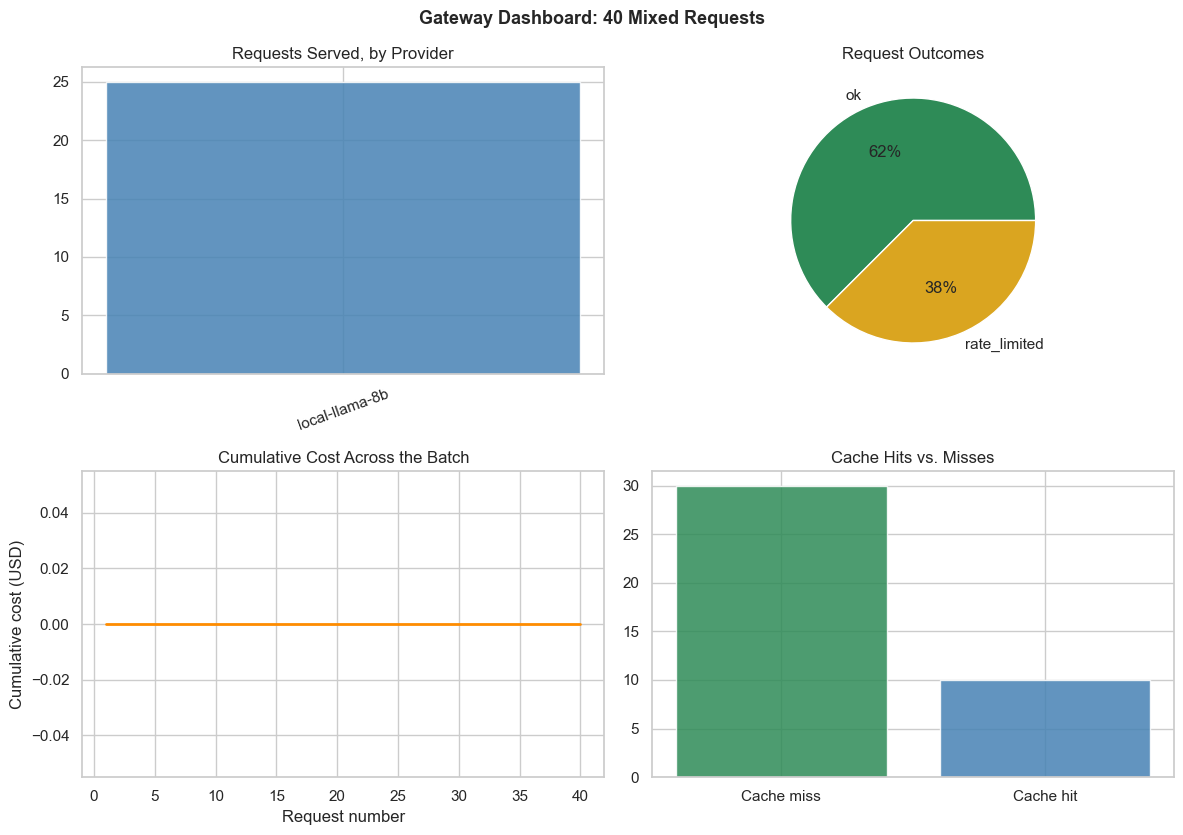

Reading this dashboard the way you would in production: are requests concentrated
on the cheapest provider (routing working), is the failure rate low (fallback
working), is cost growing linearly or leveling off (caching working)?


In [19]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8.5))
fig.suptitle("Gateway Dashboard: 40 Mixed Requests", fontweight="bold", fontsize=13)

# Panel 1: which provider actually served each request
provider_counts = log_df["provider"].value_counts(dropna=True)
axes[0, 0].bar(
    provider_counts.index, provider_counts.values, color="steelblue", alpha=0.85
)
axes[0, 0].set_title("Requests Served, by Provider")
axes[0, 0].tick_params(axis="x", rotation=20)

# Panel 2: status breakdown (ok / rate_limited / all_failed)
status_counts = log_df["status"].value_counts()
axes[0, 1].pie(
    status_counts.values,
    labels=status_counts.index,
    autopct="%1.0f%%",
    colors=["seagreen", "goldenrod", "indianred"][: len(status_counts)],
)
axes[0, 1].set_title("Request Outcomes")

# Panel 3: cumulative cost over the batch
axes[1, 0].plot(
    np.arange(1, len(log_df) + 1),
    log_df["cost_usd"].cumsum(),
    color="darkorange",
    linewidth=2,
)
axes[1, 0].set_xlabel("Request number")
axes[1, 0].set_ylabel("Cumulative cost (USD)")
axes[1, 0].set_title("Cumulative Cost Across the Batch")

# Panel 4: cache hit rate
cache_counts = log_df["cache_hit"].value_counts()
axes[1, 1].bar(
    ["Cache hit" if v else "Cache miss" for v in cache_counts.index],
    cache_counts.values,
    color=["seagreen", "steelblue"],
    alpha=0.85,
)
axes[1, 1].set_title("Cache Hits vs. Misses")

plt.tight_layout()
plt.show()

print(
    "Reading this dashboard the way you would in production: are requests concentrated"
)
print("on the cheapest provider (routing working), is the failure rate low (fallback")
print("working), is cost growing linearly or leveling off (caching working)?")

#### What Just Happened

We assembled a complete production-style gateway: caching + rate limiting + cost-aware routing + fallback + logging, all in one request lifecycle. This is the shape of every real LLM gateway — the only simulation is the providers themselves.

**The gap that motivates Part 8:** The gateway works, and the logic is production-ready, but every provider is a mock. The final step is bridging to real LLM SDKs with LiteLLM, so the exact same routing/fallback/caching logic runs against OpenAI, Anthropic, Groq, etc. **Next: from simulation to production.**


---

## Part 8a — What We Built (Simulation → Production)

### The Gateway Works — But It's All Simulated

The complete `Gateway` class in Part 7 has every production feature: routing, fallback, rate limiting, caching, logging. The only simulation is the providers themselves — they're mocks with no network calls, no API keys, and deterministic behavior.

**Why we simulated:** Reproducibility. Every reader gets the same latency numbers, the same failure rates, and the same routing decisions, regardless of whether OpenAI or Anthropic is having a good day. This makes debugging and learning straightforward.

**What's load-bearing in the real world:** The logic is production-ready. The routing strategies, fallback chains, rate limiters, and cache lookups are exactly what a real gateway does — the only difference is swapping `MockLLMProvider.complete()` for `litellm.completion()` or the native provider SDK.

---

## Part 8b — Real Gateway (LiteLLM Bridge)

### From Mocks to Real Providers in One Line

Here's how the patterns we built map onto **LiteLLM**, the most widely used open-source LLM gateway:

| Our Implementation                  | LiteLLM Equivalent                                     | Notes                              |
| ----------------------------------- | ------------------------------------------------------ | ---------------------------------- |
| `MockLLMProvider.complete()`        | `litellm.completion()`                                 | One unified call for all providers |
| Cost-sorted routing chain           | `Router(routing_strategy="cost-based-routing")`        | Picks cheapest by default          |
| `call_with_fallback(chain=[...])`   | `completion(fallbacks=["gpt-4o-mini", "groq/llama3"])` | Automatic fallback on errors       |
| In-memory cache (`self.cache = {}`) | `Router(cache=InMemoryCache())` or Redis               | Exact-match or semantic caching    |
| `TokenBucket` rate limiter          | `Router(rpm=60, tpm=100000)`                           | Per-model rate limits              |
| `gateway.logs.append(...)`          | LiteLLM's native callbacks → Langfuse, Helicone        | Structured observability logs      |

### Try It With a Real Provider (Conditional)

If you have an `OPENAI_API_KEY` set, the cell below will run one real LiteLLM call with fallback. If not, it prints a skip message — no API key required to understand the pattern.


In [ ]:
# ── Part 8b — Real Gateway: same logic, real SDKs ────────────────────────────
import os

gateway_table = [
    (
        "MockLLMProvider.complete(model, prompt)",
        "litellm.completion(model=model, messages=[...])",
    ),
    ("cost-sorted routing", "Router(routing_strategy='cost-based-routing')"),
    (
        "call_with_fallback(chain)",
        "completion(fallbacks=['gpt-4o-mini', 'claude-haiku'])",
    ),
    ("CachingProvider in-memory dict", "Router(cache=RedisCache(...))"),
]

print("Our Simulation  →  LiteLLM Production Equivalent")
print("─" * 70)
for sim, prod in gateway_table:
    print(f"  {sim}")
    print(f"  → {prod}")
    print()

api_key = os.environ.get("OPENAI_API_KEY")
if api_key:
    try:
        import litellm

        resp = litellm.completion(
            model="gpt-4o-mini",
            messages=[
                {"role": "user", "content": "Say 'Gateway bridge works!' in 5 words."}
            ],
            fallbacks=["claude-haiku-4-5"],
            max_tokens=20,
        )
        print(f"Live call succeeded: {resp.choices[0].message.content}")
    except Exception as e:
        print(f"Live call skipped: {e}")
else:
    print(
        "Skipping live call — set OPENAI_API_KEY to run a real litellm.completion() call."
    )
    print("Same .completion() call, same routing/fallback/caching logic —")
    print("the only difference is MockLLMProvider vs. real SDKs underneath.")

### Popular Gateways Compared

| Gateway                   | Type        | Best For                                                     |
| ------------------------- | ----------- | ------------------------------------------------------------ |
| **LiteLLM**               | Open-source | Broadest provider coverage; easy to self-host                |
| **Portkey**               | SaaS / OSS  | Strong observability dashboard, prompt management            |
| **Helicone**              | SaaS / OSS  | Drop-in proxy with polished logging UI                       |
| **Cloudflare AI Gateway** | SaaS        | Already on Cloudflare's edge — one-click setup, edge caching |
| **Kong AI Gateway**       | Enterprise  | Built on Kong's API gateway, deep enterprise features        |
| **OpenRouter**            | SaaS        | Easiest single-account access to 100+ hosted models          |

For most teams, **LiteLLM** is the natural starting point: open source, runs anywhere, and its API shape is close to what we built by hand above.

### Production Checklist

| #   | Practice                                                     | Why It Matters                                                      |
| --- | ------------------------------------------------------------ | ------------------------------------------------------------------- |
| 1   | Use a shared cache (Redis), not in-memory                    | Survives restarts and is shared across replicas                     |
| 2   | Set per-user and per-team rate limits                        | Stops one bad actor or bug from burning the whole budget            |
| 3   | Log to a real observability backend                          | Langfuse, Helicone, Arize, or your own database                     |
| 4   | Use a master key plus virtual keys per team                  | Enables audit trails and internal chargebacks                       |
| 5   | Pin model versions in config                                 | Avoids silent behavior changes when a provider updates a model      |
| 6   | Always set timeouts and a max retry count                    | Prevents one hung call from blocking a whole request queue          |
| 7   | Redact PII before logging prompts                            | Keeps emails, phone numbers, and IDs out of your logs               |
| 8   | Health-check each deployment and auto-disable unhealthy ones | Removes a failing provider from rotation before users notice        |
| 9   | Run the gateway with autoscaling                             | Scales gateway capacity with traffic, not just provider capacity    |
| 10  | Version the gateway config in Git                            | Treats routing and fallback rules as code, with review and rollback |


---

## Summary: The LLM Gateway Mental Model

### Journey Completed — From Pain Point to Production

We started with the pain of calling multiple LLM providers directly (different SDKs, no fallback, scattered costs) and built a complete gateway from first principles. Here's what we covered, step by step:

| ✅ | Step | Concept                         | What We Built                                                          |
| - | ---- | -------------------------------- | ---------------------------------------------------------------------- |
| ✅ | 1    | The Multi-Provider Problem       | Demonstrated the brittleness of direct provider calls                   |
| ✅ | 2    | Unified Provider Abstraction     | `MockLLMProvider` — one interface for all providers                     |
| ✅ | 3    | Round-Robin & Least-Busy Routing | Load distribution strategies: fixed vs. adaptive                        |
| ✅ | 4    | Latency-Aware Routing            | `LatencyAwareRouter` with EMA learning                                  |
| ✅ | 5    | Cost-Aware & Weighted Routing    | Cheapest-first routing + proportional traffic splitting                 |
| ✅ | 6    | Rate Limiting & Throttling       | `TokenBucket` and `SlidingWindowLimiter` with quantified burst tolerance |
| ✅ | 7    | Fallback Strategies              | Multi-provider chains with proven multiplicative reliability             |
| ✅ | 8    | Cost Optimization via Caching    | `CachingProvider` with measured hit rates and savings                   |
| ✅ | 9    | Assembling a Production Gateway  | Complete `Gateway` class combining all mechanisms                       |
| ✅ | 10   | Real-World Gateways & Practices  | LiteLLM bridge, gateway comparison, production checklist                 |

**Every concept was demonstrated with working code and measurements** — routing distributions, fallback success rates, cache hit rates, cost savings, and burst tolerance, all measured and visualized.

### Key Insights to Keep

1. **A gateway's first job is normalization** — every downstream feature (routing, caching, fallback) depends on treating all providers identically. Without a unified interface, nothing else scales.

2. **Routing strategies optimize for different goals** — round-robin for fairness, least-busy for throughput, latency-aware for speed, cost-aware for budget. Pick the strategy that matches your priority, and be ready to change it.

3. **Reliability is multiplicative across fallback chains** — three providers at 98% uptime each ≈ 99.9992% overall. Fallback is the single biggest reliability lever, and it's almost free to implement once normalization is in place.

4. **Caching is usually the highest-leverage cost optimization** — and the simplest. Exact-match caching alone captures most of the savings for FAQ-style traffic, no semantic matching needed.

5. **Rate limiting protects both your budget and your provider relationship** — token buckets tolerate bursts (good for interactive apps), sliding windows give hard guarantees (good for contractual limits). Measure burst tolerance, don't guess.

6. **Production gateways are just these five pieces composed** — normalization + routing + rate limiting + fallback + caching, with observability at every step. The logic is identical whether the providers are mocks or real SDKs.

### When to Use What

| Scenario                                         | Recommended Approach                                     |
| -------------------------------------------------- | ------------------------------------------------------------ |
| High-volume, low-stakes tasks (classification, tagging) | Cost-aware routing to the cheapest capable model            |
| User-facing, latency-sensitive chat                     | Latency-aware routing, tight timeouts, fast fallback         |
| Canary rollout of a new model                           | Weighted routing, gradually shifting the split                |
| Provider outages are a real business risk                | Multi-provider fallback chain, health checks                  |
| Repeated or FAQ-style traffic                            | Response caching (exact-match first, semantic caching later)  |
| Multi-team usage, shared budget                          | Per-user/per-team rate limits plus per-key cost attribution   |

### Next Steps

1. **Swap the mocks for real calls** — replace `MockLLMProvider` with `litellm.completion()` and re-run the fallback and cost-tracking demos against live providers.

2. **Add Redis-backed caching** — so cache state survives restarts and is shared across gateway replicas.

3. **Wire logs into an observability tool** — send the gateway's logs to Langfuse, Helicone, or your own database instead of a local DataFrame.

4. **Add per-user rate limits** — on top of the global limiter, track budgets by user ID or team to prevent one bad actor from burning the whole budget.

---

**Final Takeaway:** An LLM Gateway isn't a single monolithic feature — it's the composition of small, individually simple pieces (normalize, route, limit, fall back, cache, log) that together turn "call an LLM" from a fragile, single-provider integration into a resilient, cost-aware, observable production system. Build it piece by piece, measure each mechanism's impact, and the complexity compounds into reliability.
